# Benchmark of ML models

### Decision tree regressor

In [51]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from pickle import load

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [48]:
# Read the best fit hyperparameters
file = open('../src/data_mining/trained_models/rf_model_tuned_v1.pkl', 'rb')
best_fit_model = load(file)
file.close()

ModuleNotFoundError: No module named 'pycaret'

In [9]:
df = read_csv('../data/final_datasets/transformed_datasets/transformed_training_data.csv')
for col, corr in zip(df.columns, df.corr(method='spearman')['UHI Index']):
    print(col, corr)

gndvi_median_res10 -0.23242072169639502
datt1_median_res10 -0.10108123020924105
fs_median_res10 0.23669203740624217
siwsi_median_res10 -0.23756384399757405
ndmi_median_res10 -0.19692658420060125
si_median_res10 0.14768125141276878
w_median_res10 -0.13322188268910745
evi_median_res10 -0.20325645482723342
B2_median_res10 0.17331527364580235
B3_median_res10 0.1707866849907093
B4_median_res10 0.1721538369503773
B5_median_res10 0.16861792634929842
B7_median_res10 -0.10985123255260303
B8_median_res10 -0.1322424711376458
B8A_median_res10 -0.12267888198808166
B11_median_res10 0.10195918314314867
B12_median_res10 0.18389258468059266
gndvi_median_res100 -0.26960740029197466
fs_median_res100 0.2837008754309153
siwsi_median_res100 -0.24280627620865802
ndmi_median_res100 -0.2106285087572004
si_median_res100 0.20226765685218298
w_median_res100 -0.21816191047909567
evi_median_res100 -0.17787421787852986
B2_median_res100 0.3533079227784651
B3_median_res100 0.3587435015314258
B4_median_res100 0.3560548

In [53]:
# Taken from https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py

df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rgr = DecisionTreeRegressor(random_state = 0)
path = rgr.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

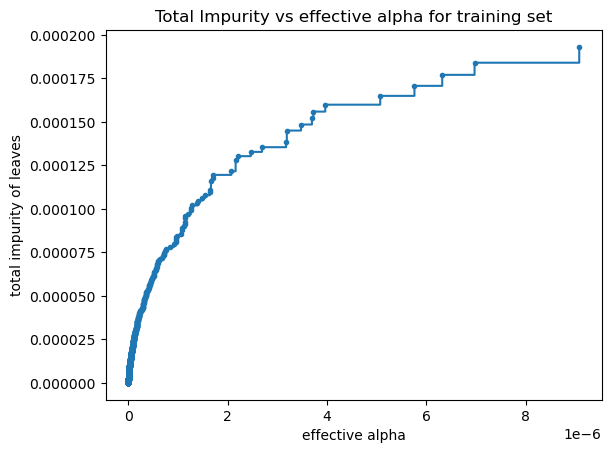

In [54]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", markersize = 3.0, drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [56]:
rgrs = []
for ccp_alpha in ccp_alphas[1:]:
    rgr = DecisionTreeRegressor(random_state = 0, 
                                ccp_alpha = ccp_alpha, 
                                criterion = 'squared_error', 
                                max_features = 0.8, 
                                min_samples_split = 0.00017239623972536324,
                                min_samples_leaf = 0.0006733944396699074,
                                splitter = 'best')
    rgr.fit(X_train, y_train)
    rgrs.append(rgr)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(rgrs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 3 with ccp_alpha: 6.963031797549906e-05


In [57]:
total_sum = 0.0

for rgr in rgrs:
    total_sum += rgr.feature_importances_
    
# Compute the mean of the feature importances
total_sum = total_sum/len(total_sum)

In [58]:
corr = df.corr(method = 'spearman')

In [59]:
for column, correlation, importance in zip(df.columns[:-1], corr['UHI Index'].values[:-1], total_sum):
    print(column, correlation, importance)

gndvi_median_res100 -0.26960740029197466 1.4624143620228276
fs_median_res100 0.2837008754309153 0.3414594539237636
siwsi_median_res100 -0.24280627620865802 0.6326973910560318
si_median_res100 0.20226765685218298 2.2152781895808484
w_median_res100 -0.21816191047909567 0.6338314125178464
evi_median_res100 -0.17787421787852986 0.6561093216767717
B6_median_res100 0.10596795827905821 0.5806974439674495
gndvi_median_res250 -0.2193487371527983 0.5811790393468454
fs_median_res250 0.27077150335948813 1.954669594497139
siwsi_median_res250 -0.23476482353140354 0.6574992511489757
ndmi_median_res250 -0.21439003704789072 0.3221390918003011
si_median_res250 0.1567314794410387 1.3876250779337274
w_median_res250 -0.3251936237594454 0.6803475328676768
evi_median_res250 -0.11001918994187013 2.466751455121173
B2_median_res250 0.41637098864427635 0.629576030181212
B5_median_res250 0.44410122140350244 0.4468377128132177
B6_median_res250 0.209294284833095 0.6831696690930021
B8_median_res250 0.092017206773294

Los que más suman son: LST, Polygon density y Air temperature at surface

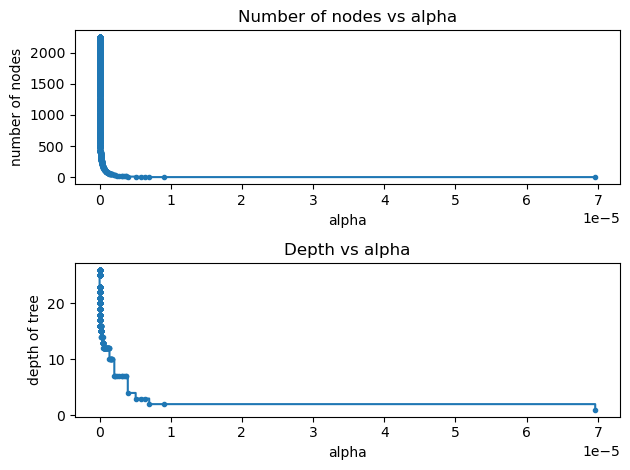

In [60]:
node_counts = [rgr.tree_.node_count for rgr in rgrs]
depth = [rgr.tree_.max_depth for rgr in rgrs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas[1:], node_counts, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

ax[1].plot(ccp_alphas[1:], depth, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

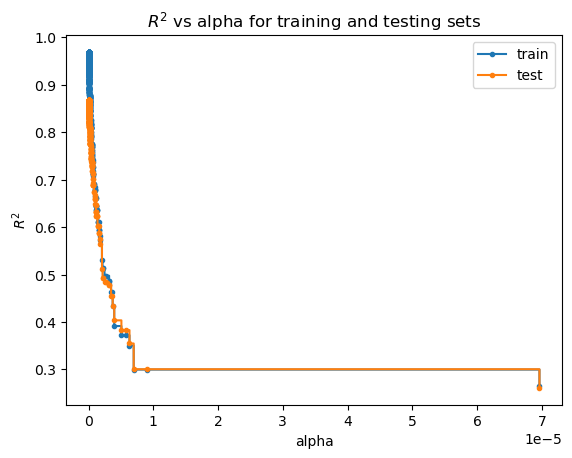

In [61]:
train_predictions = [rgr.predict(X_train) for rgr in rgrs]
test_predictions = [rgr.predict(X_test) for rgr in rgrs]

r2_train = [r2_score(y_train, y_pred) for y_pred in train_predictions]
r2_test = [r2_score(y_test, y_pred) for y_pred in test_predictions]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

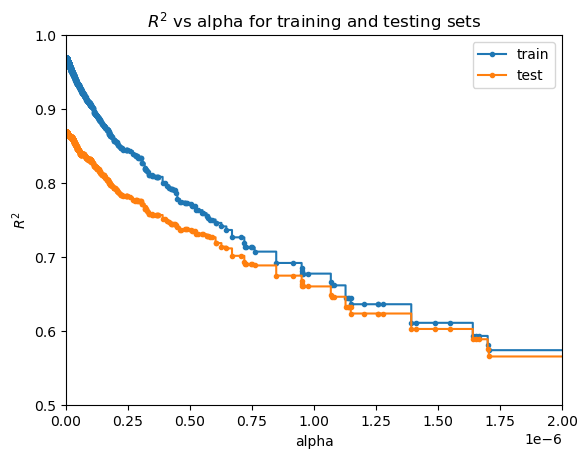

In [62]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.set_xlim(0.0, 0.2e-5)
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.show()

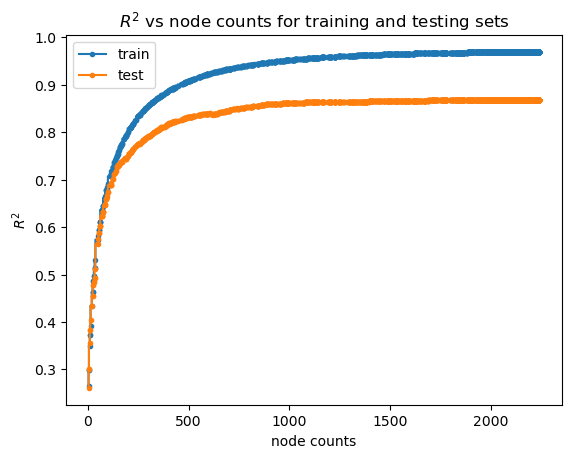

In [63]:
fig, ax = plt.subplots()
ax.set_xlabel("node counts")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs node counts for training and testing sets")
ax.plot(node_counts, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(node_counts, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

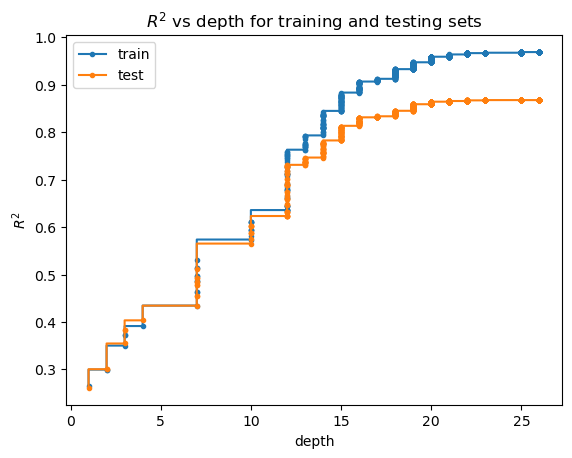

In [64]:
fig, ax = plt.subplots()
ax.set_xlabel("depth")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs depth for training and testing sets")
ax.plot(depth, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(depth, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

### Random forest regressor

In [66]:
# Packages
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import make_scorer
r2 = make_scorer(r2_score)
from sklearn.inspection import permutation_importance
from pandas import read_csv, Series
from numpy import std

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [67]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Model
rfr = RandomForestRegressor(n_estimators = 1000, 
                            criterion = 'squared_error',
                            ccp_alpha = 5.93279137e-20, 
                            max_features = 0.8, 
                            max_leaf_nodes = 1900,
                            min_samples_split = 0.00017239623972536324,
                            min_samples_leaf = 0.0006733944396699074, 
                            max_depth = 20,
                            random_state = 10)

In [68]:
# Fit the model
rfr.fit(X_train, y_train)

RandomForestRegressor(ccp_alpha=5.93279137e-20, max_depth=20, max_features=0.8,
                      max_leaf_nodes=1900,
                      min_samples_leaf=0.0006733944396699074,
                      min_samples_split=0.00017239623972536324,
                      n_estimators=1000, random_state=10)

In [69]:
# Compute importances
importances = rfr.feature_importances_

# Compute standard deviation for each feature importance
importances_std = std([tree.feature_importances_ for tree in rfr.estimators_], axis = 0)

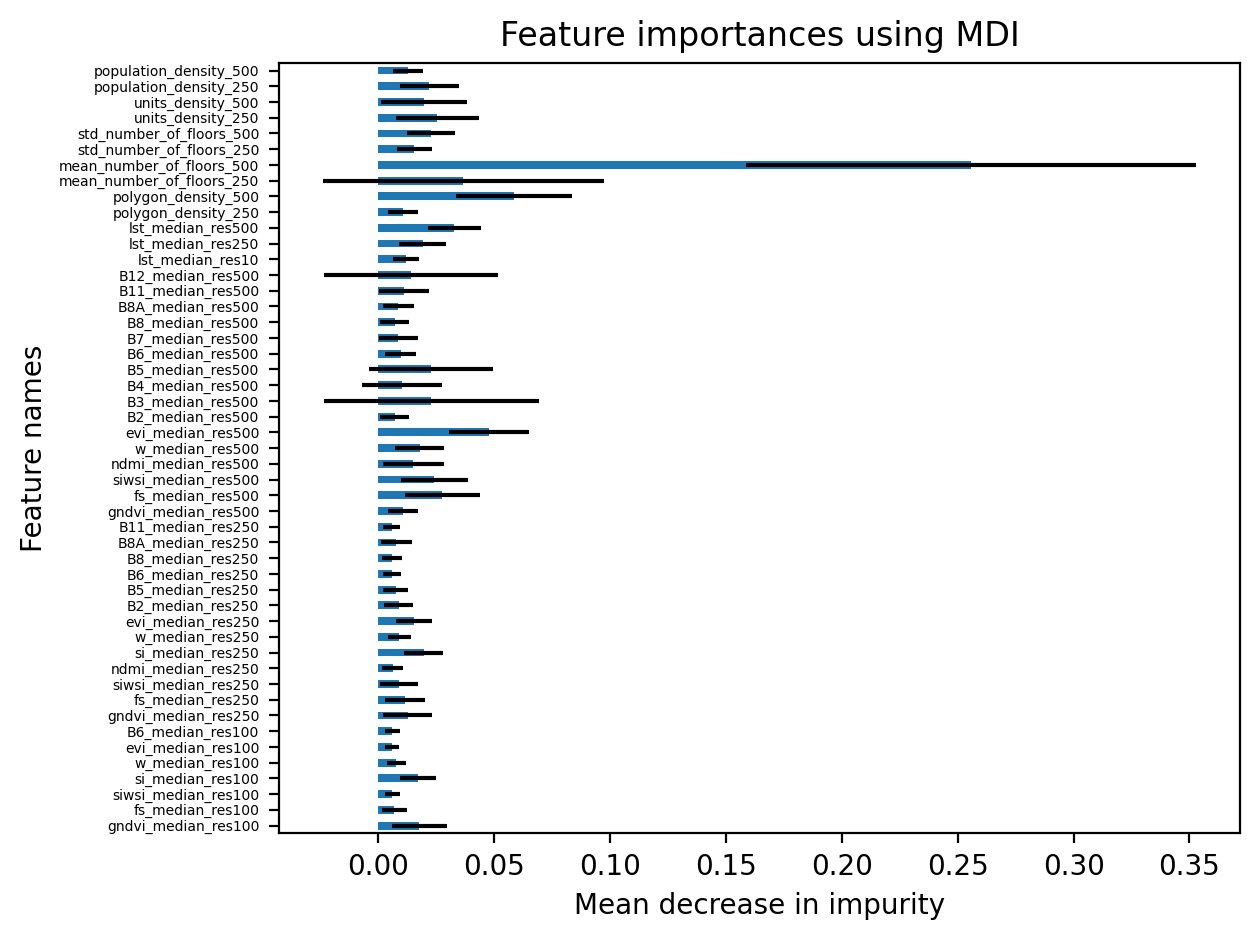

In [70]:
# Impurity-based importance plot
forest_importances = Series(importances, index = X_train.columns)

fig, ax = plt.subplots(1, 1, dpi = 200)
forest_importances.plot.barh(xerr = importances_std, ax = ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Feature names")
ax.set_xlabel("Mean decrease in impurity")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()

In [71]:
print(r2_score(y_train, rfr.predict(X_train)))
print(r2_score(y_test, rfr.predict(X_test)))

0.9749497214105706
0.9398564625406816


In [72]:
# Compute permutation importance
result = permutation_importance(rfr, X_test, y_test, scoring = r2, n_repeats = 10, random_state = 42)

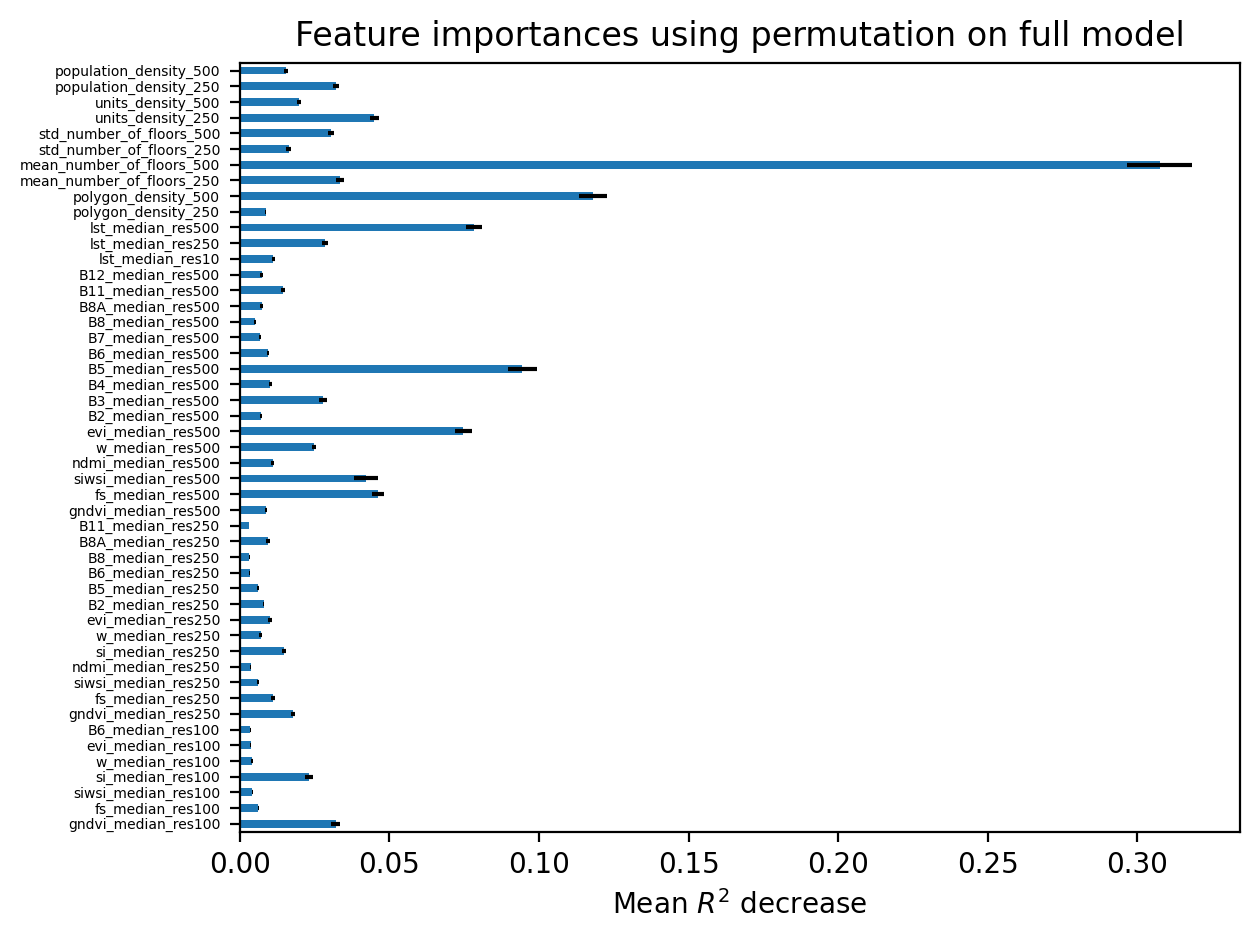

In [73]:
# Covert importances to Series object
forest_permutation_importances = Series(result.importances_mean, index = X_train.columns)

# Plot the importance ranking
fig, ax = plt.subplots(1, 1, dpi = 200)
forest_permutation_importances.plot.barh(xerr = result.importances_std, ax = ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_xlabel("Mean $R^{2}$ decrease")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()
plt.show()

### XGBoost regressor

In [53]:
# Packages
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import logspace
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [54]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_maxreduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

# XGBoost Regressor
xgbr = XGBRegressor(nthread = -1, 
                    colsample_bylevel = 0.26039175857141017,
                    colsample_bynode = 0.0026795271301607616,
                    colsample_bytree = 0.17273120612209947, 
                    eta = 0.23140004684157492,
                    gamma = 3.2666575813880865e-06,
                    max_depth = 12,
                    min_child_weight = 1.710210297185527,
                    reg_alpha = 2.8399331769460818e-06,
                    reg_lambda = 0.38787583265517744,
                    subsample = 0.9850474055600175,
                    tree_method = 'exact',
                    random_state = 10)

In [55]:
# Train the model
xgbr.fit(X_train.values, y_train.values)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.26039175857141017,
             colsample_bynode=0.0026795271301607616,
             colsample_bytree=0.17273120612209947, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.23140004684157492, eval_metric=None, feature_types=None,
             gamma=3.2666575813880865e-06, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
             max_leaves=None, min_child_weight=1.710210297185527, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, nthread=-1, ...)

In [56]:
# Predict
train_predictions = xgbr.predict(X_train.values)
test_predictions = xgbr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9970659582690015
R^2 over test data: 0.9425060348355687


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

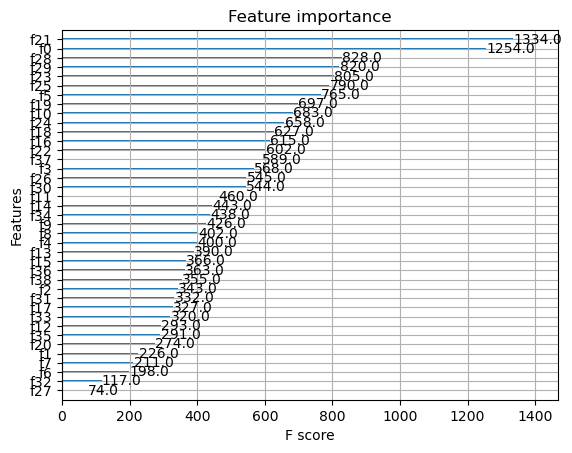

In [57]:
plot_importance(xgbr)

In [58]:
xgbr.feature_importances_*100.0

array([ 4.7783217 ,  0.08679979,  0.61861545,  2.8677752 ,  5.414277  ,
        4.055421  ,  0.05921445,  0.18518192,  0.4223071 ,  0.30488503,
        0.238789  ,  0.5644869 ,  1.7844058 ,  0.6068303 ,  0.19134712,
        2.8961906 ,  0.82090664,  0.11745696,  9.091583  ,  3.1824236 ,
        3.8547273 ,  0.54186034,  3.4334774 ,  0.8022307 ,  1.5663656 ,
        0.8874842 ,  3.4307976 ,  0.53507024,  1.9359041 ,  3.2928705 ,
        6.5100694 ,  2.3371847 ,  0.13397232,  3.5663512 ,  1.122637  ,
        3.2038894 , 12.583666  ,  2.313702  ,  9.660519  ], dtype=float32)

In [62]:
# Set array of eta values
eta = logspace(-5, 0, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, eta_value in enumerate(eta):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.26039175857141017,
                        colsample_bynode = 0.0026795271301607616,
                        colsample_bytree = 0.17273120612209947, 
                        eta = eta_value,
                        gamma = 3.2666575813880865e-06,
                        max_depth = 12,
                        min_child_weight = 1.710210297185527,
                        reg_alpha = 2.8399331769460818e-06,
                        reg_lambda = 0.38787583265517744,
                        subsample = 0.9850474055600175,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

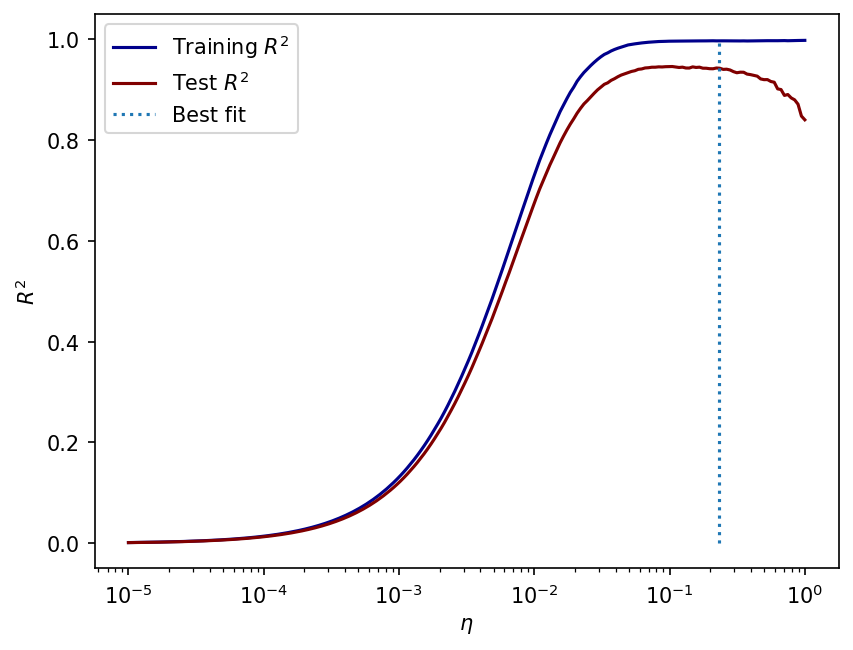

In [63]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(eta, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(eta, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.23140004684157492, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.vlines(7.0e-2, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('$\eta$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [64]:
# Set array of eta values
reg_lambda = logspace(-6, 0, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, lambda_value in enumerate(reg_lambda):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.26039175857141017,
                        colsample_bynode = 0.0026795271301607616,
                        colsample_bytree = 0.17273120612209947, 
                        eta = 0.23140004684157492,
                        gamma = 3.2666575813880865e-06,
                        max_depth = 12,
                        min_child_weight = 1.710210297185527,
                        reg_alpha = 2.8399331769460818e-06,
                        reg_lambda = lambda_value,
                        subsample = 0.9850474055600175,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

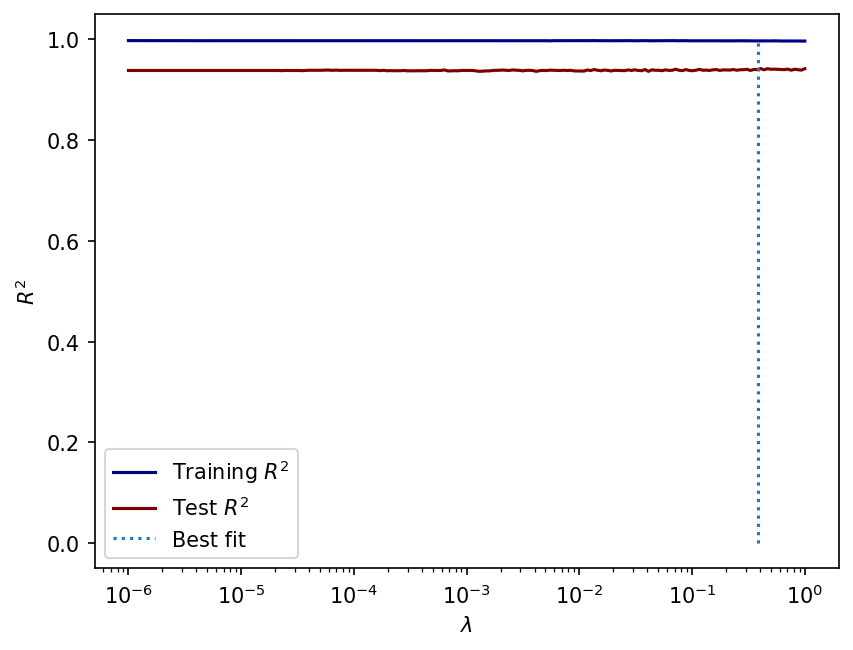

In [65]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_lambda, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_lambda, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.38787583265517744, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [66]:
# Set array of eta values
reg_alpha = logspace(-9, 1, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, alpha_value in enumerate(reg_alpha):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.26039175857141017,
                        colsample_bynode = 0.0026795271301607616,
                        colsample_bytree = 0.17273120612209947, 
                        eta = 0.23140004684157492,
                        gamma = 3.2666575813880865e-06,
                        max_depth = 12,
                        min_child_weight = 1.710210297185527,
                        reg_alpha = alpha_value,
                        reg_lambda = 0.38787583265517744,
                        subsample = 0.9850474055600175,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

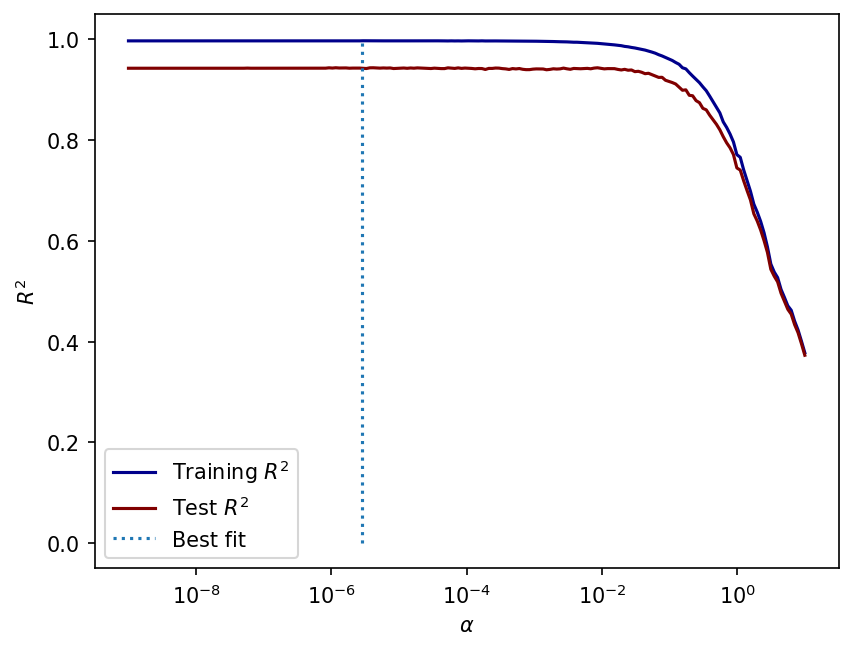

In [67]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_alpha, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_alpha, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(2.8399331769460818e-06, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [15]:
# Set array of depth values
depth = [i for i in range(1, 16, 1)]

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for depth_value in depth:
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.00025590970573705074,
                        colsample_bynode = 0.0016125310507609189,
                        colsample_bytree = 0.7224831748725747,
                        eta = 0.18997582778109562,
                        gamma = 4.495813828450373e-06,
                        max_depth = depth_value,
                        min_child_weight = 8.796462044636197e-05,
                        reg_alpha = 1.3618213880575843e-07,
                        reg_lambda = 2.0516109493758132e-07,
                        subsample = 0.52161392755372,
                        tree_method = 'auto',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(depth_value))

Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished


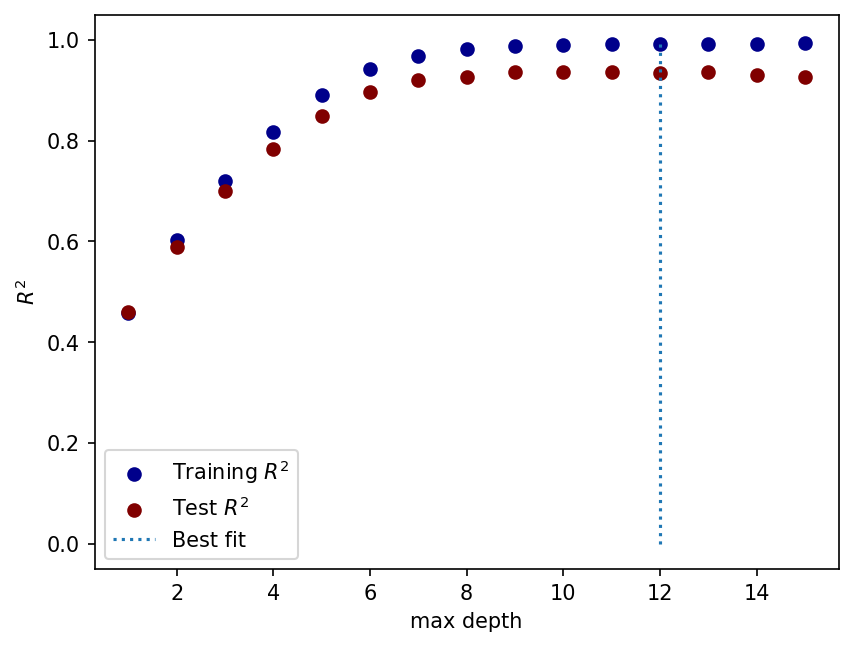

In [16]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.scatter(depth, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.scatter(depth, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(12, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xlabel('max depth')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

### KNN Regressor

In [20]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import arange, int64
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [21]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/interactions_datasets/interactions_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# KNN Regressor
"""knnr = KNeighborsRegressor(weights = 'distance',
                           n_neighbors = 194, 
                           leaf_size = 356,
                           algorithm = 'kd_tree')"""
knnr = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 2, 
                            p = 2, 
                            weights = 'distance')

In [22]:
# Train the model
knnr.fit(X_train.values, y_train.values)

KNeighborsRegressor(metric='manhattan', n_jobs=1, n_neighbors=2, p=1,
                    weights='distance')

In [23]:
# Predict
train_predictions = knnr.predict(X_train.values)
test_predictions = knnr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 1.0
R^2 over test data: 0.9711823950211231


In [24]:
# Set array of eta values
k = arange(1, 101, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, k_value in enumerate(k):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = 30, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = k_value, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

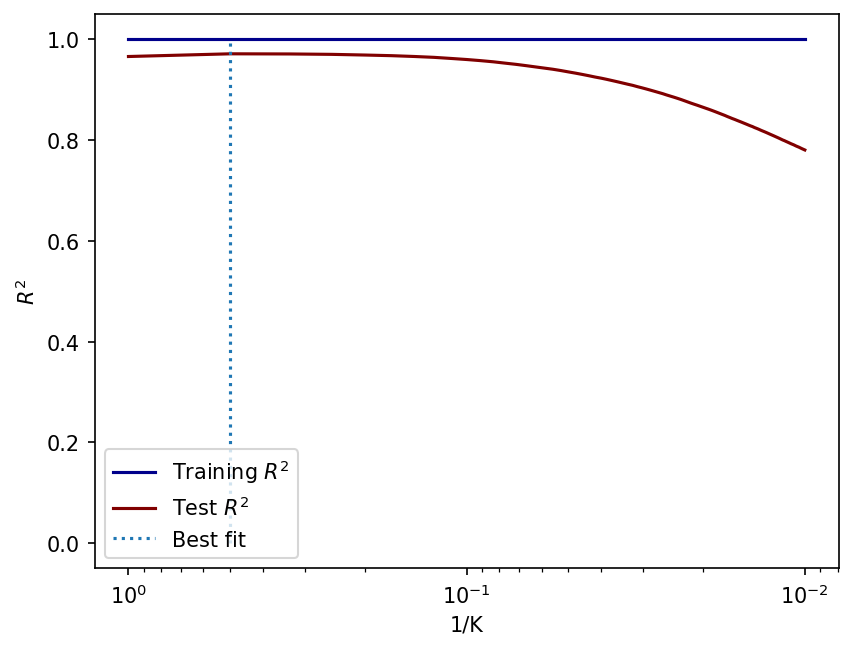

In [25]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(1/k, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(1/k, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1/2, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('1/K')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [122]:
# Set array of eta values
leaf_size = arange(1, 201, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, leaf_value in enumerate(leaf_size):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = leaf_value, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = 3, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

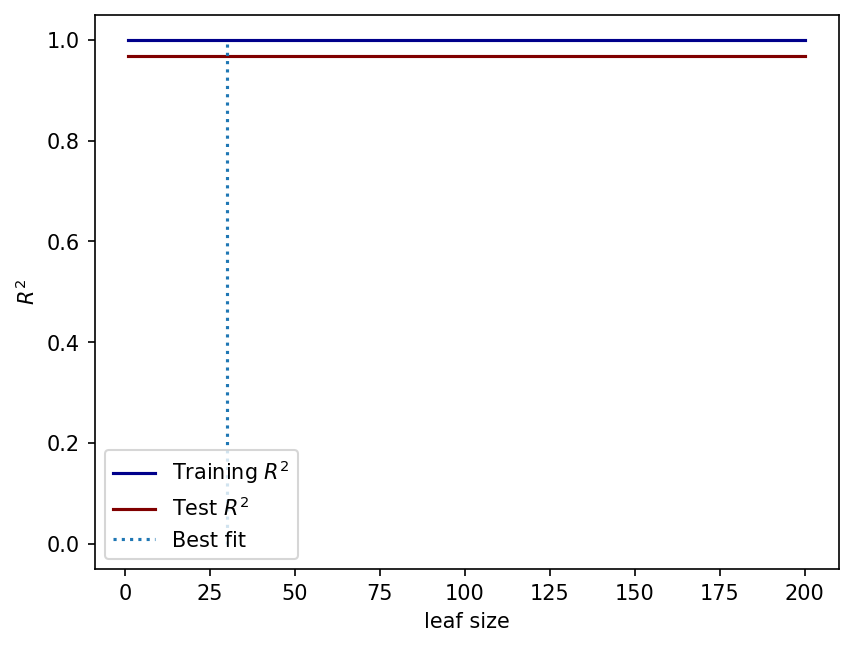

In [123]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(leaf_size, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(leaf_size, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(30, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xscale('log')
ax.set_xlabel('leaf size')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

### Ada Boost Regressor

In [6]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import arange, logspace, int32
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Ada Boost Regressor
abr = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state = 0, max_depth = 5), random_state = 10)

In [3]:
# Train the model
abr.fit(X_train.values, y_train.values)

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5, random_state=0),
                  random_state=10)

In [4]:
# Predict
train_predictions = abr.predict(X_train.values)
test_predictions = abr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.7479893459064457
R^2 over test data: 0.7329556041939518


In [7]:
# Set array of learning rates values
learning_rate = logspace(-4, 0, 100)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, lr_value in enumerate(learning_rate):
    # Set a new model
    abr = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state = 0, max_depth = 5),
                            learning_rate = lr_value,
                            random_state = 10)
    
    # Train the model
    abr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = abr.predict(X_train.values)
    test_predictions = abr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

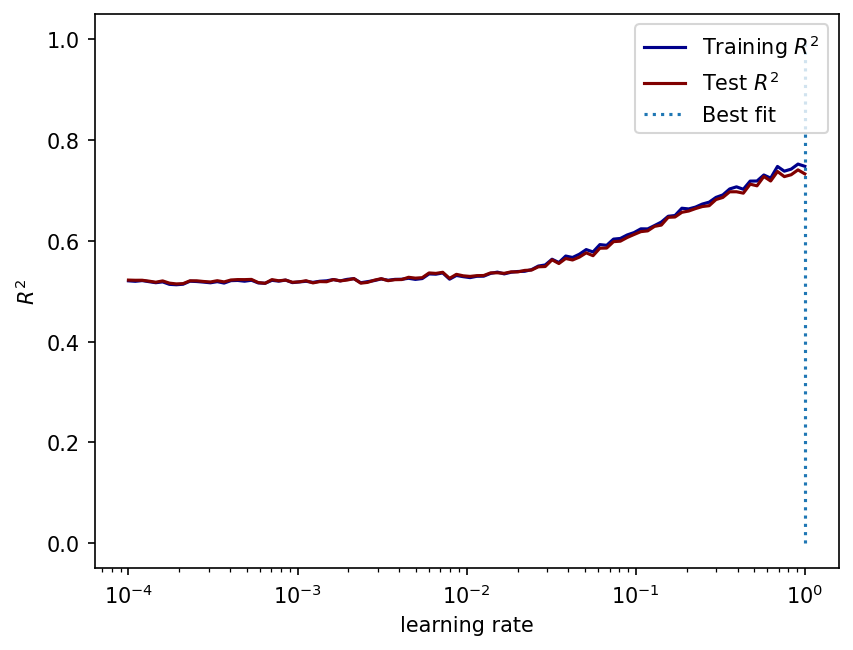

In [8]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(learning_rate, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(learning_rate, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1.0, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('learning rate')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [11]:
# Set array of the number of estimators
n_estimators = arange(100, 201, 2, dtype = int32)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, n in enumerate(n_estimators):
    # Set a new model
    abr = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state = 0, max_depth = 5),
                            n_estimators = n,
                            random_state = 10)
    
    # Train the model
    abr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = abr.predict(X_train.values)
    test_predictions = abr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

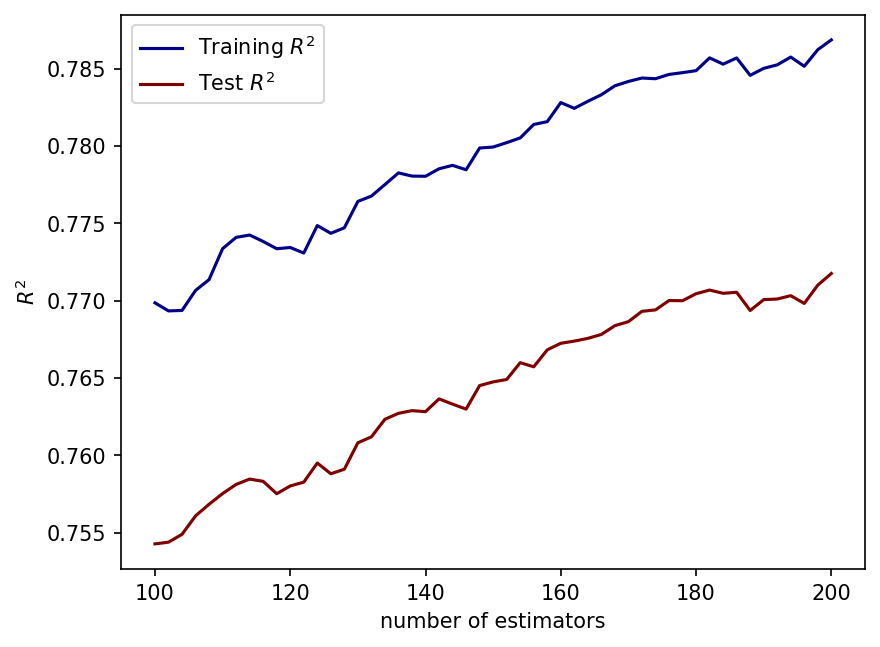

In [13]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(n_estimators, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(n_estimators, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
#ax.vlines(50, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xscale('log')
ax.set_xlabel('number of estimators')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [16]:
df_interactions = read_csv('../data/final_datasets/transformed_datasets/interactions_datasets/interactions_reduced_training_data.csv')

In [17]:
df_interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 95 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gndvi_median_res100       11229 non-null  float64
 1   fs_median_res100          11229 non-null  float64
 2   siwsi_median_res100       11229 non-null  float64
 3   si_median_res100          11229 non-null  float64
 4   w_median_res100           11229 non-null  float64
 5   evi_median_res100         11229 non-null  float64
 6   B6_median_res100          11229 non-null  float64
 7   gndvi_median_res250       11229 non-null  float64
 8   fs_median_res250          11229 non-null  float64
 9   siwsi_median_res250       11229 non-null  float64
 10  ndmi_median_res250        11229 non-null  float64
 11  si_median_res250          11229 non-null  float64
 12  w_median_res250           11229 non-null  float64
 13  evi_median_res250         11229 non-null  float64
 14  B2_med

In [19]:
for col, cor in zip(df_interactions.columns, df_interactions.corr(method='spearman')['UHI Index'].values):
    print(col, cor)

gndvi_median_res100 -0.26960740029197466
fs_median_res100 0.2837008754309153
siwsi_median_res100 -0.24280627620865802
si_median_res100 0.20226765685218298
w_median_res100 -0.21816191047909567
evi_median_res100 -0.17787421787852986
B6_median_res100 0.10596795827905821
gndvi_median_res250 -0.2193487371527983
fs_median_res250 0.27077150335948813
siwsi_median_res250 -0.23476482353140354
ndmi_median_res250 -0.21439003704789072
si_median_res250 0.1567314794410387
w_median_res250 -0.3251936237594454
evi_median_res250 -0.11001918994187013
B2_median_res250 0.41637098864427635
B5_median_res250 0.44410122140350244
B6_median_res250 0.209294284833095
B8_median_res250 0.09201720677329445
B8A_median_res250 0.08461085864888286
B11_median_res250 0.4109544754017272
gndvi_median_res500 -0.12387542142333542
fs_median_res500 0.25883624930400323
siwsi_median_res500 -0.24766273218600918
ndmi_median_res500 -0.22629272829420555
w_median_res500 -0.36268964017046657
evi_median_res500 -0.11274960565233137
B2_medi

In [41]:
df_to_reduce = read_csv('../data/final_datasets/transformed_datasets/transformed_test_data.csv')

In [42]:
df_to_reduce.drop(columns = ['datt1_median_res10',
'B2_median_res10',
'B4_median_res10',
'ndmi_median_res10',
'si_median_res10',
'w_median_res10',
'B3_median_res10',
'B5_median_res10',
'B7_median_res10',
'B8_median_res10',
'evi_median_res10',
'B8A_median_res10',
'siwsi_median_res10',
'B4_median_res100',
'gndvi_median_res10',
'B11_median_res10',
'B12_median_res10',
'fs_median_res10',
'B3_median_res100',
'B5_median_res100',
'B2_median_res100',
'B3_median_res250',
'ndmi_median_res100',
'B12_median_res100',
'B12_median_res250',
'B4_median_res250',
'B7_median_res250',
'B11_median_res100',
'siwsi_median_res100',
'fs_median_res100',
'B6_median_res100',
'B2_median_res250',
'evi_median_res100',
'B11_median_res250',
'B8_median_res250',
'ndmi_median_res250',
'B6_median_res250',
'B5_median_res250',
'B2_median_res500'], inplace = True)

In [43]:
df_to_reduce.to_csv('../data/final_datasets/transformed_datasets/transformed_maxreduced_test_data.csv')